Setup & Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

sns.set(style="whitegrid", context="notebook")
plt.style.use("default")

DATA_PATH = Path("./diabetic_data.csv")


Load Data & Basic EDA

- distributions, missingness, target balance.

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Column types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glime

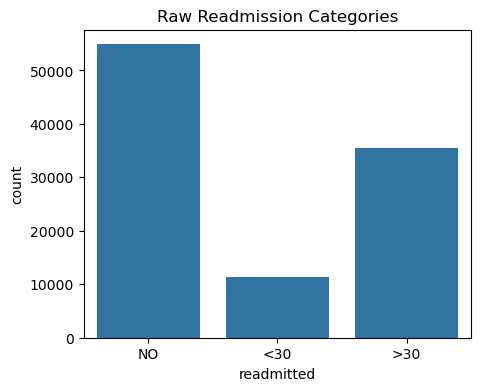


Number of '?' per column:
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
tolbutamide              0
pioglitazone             0
rosiglitazone            0
acarbose                 0
miglitol                 0
dtype: int64


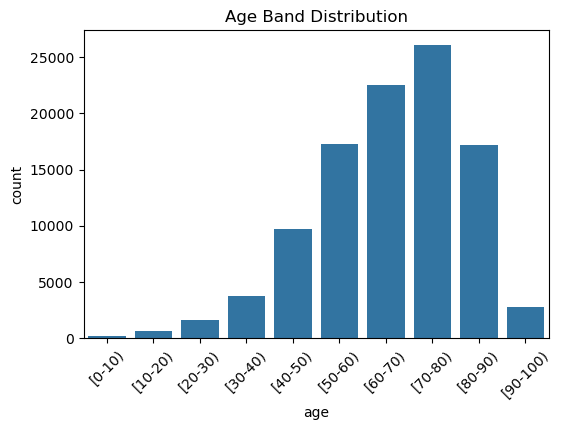

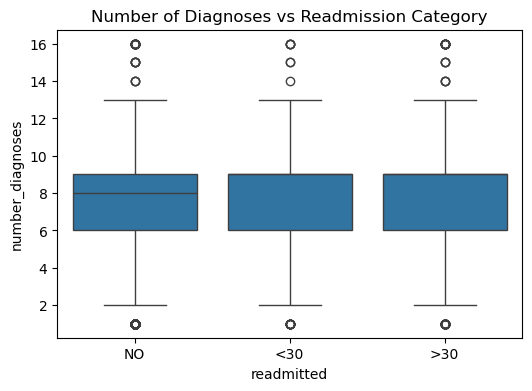

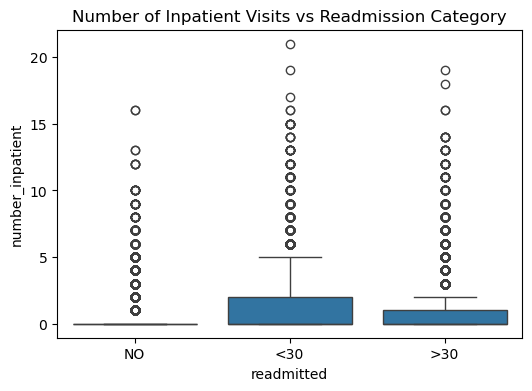

In [22]:
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

print("\nColumn types:")
print(df_raw.dtypes)

print("\nBasic info:")
print(df_raw.info())

print("\nRaw 'readmitted' value counts:")
print(df_raw["readmitted"].value_counts(dropna=False))

plt.figure(figsize=(5, 4))
sns.countplot(x="readmitted", data=df_raw, order=["NO", "<30", ">30"])
plt.title("Raw Readmission Categories")
plt.show()

missing_summary = (df_raw == "?").sum().sort_values(ascending=False)
print("\nNumber of '?' per column:")
print(missing_summary.head(15))

plt.figure(figsize=(6, 4))
sns.countplot(
    x="age",
    data=df_raw,
    order=["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
           "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
)
plt.xticks(rotation=45)
plt.title("Age Band Distribution")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(
    x="readmitted",
    y="number_diagnoses",
    data=df_raw,
    order=["NO", "<30", ">30"]
)
plt.title("Number of Diagnoses vs Readmission Category")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(
    x="readmitted",
    y="number_inpatient",
    data=df_raw,
    order=["NO", "<30", ">30"]
)
plt.title("Number of Inpatient Visits vs Readmission Category")
plt.show()


Preprocessing & Feature Engineering

- This function encodes everything into a numeric X and binary y (30-day readmission).

C:\Users\aznga\AppData\Local\Temp\ipykernel_31368\2539787440.py:72: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(
C:\Users\aznga\AppData\Local\Temp\ipykernel_31368\2539787440.py:72: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(
C:\Users\aznga\AppData\Local\Temp\ipykernel_31368\2539787440.py:72: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To

Processed X shape: (99340, 60)
Target distribution:
 readmitted
0    0.52873
1    0.47127
Name: proportion, dtype: float64


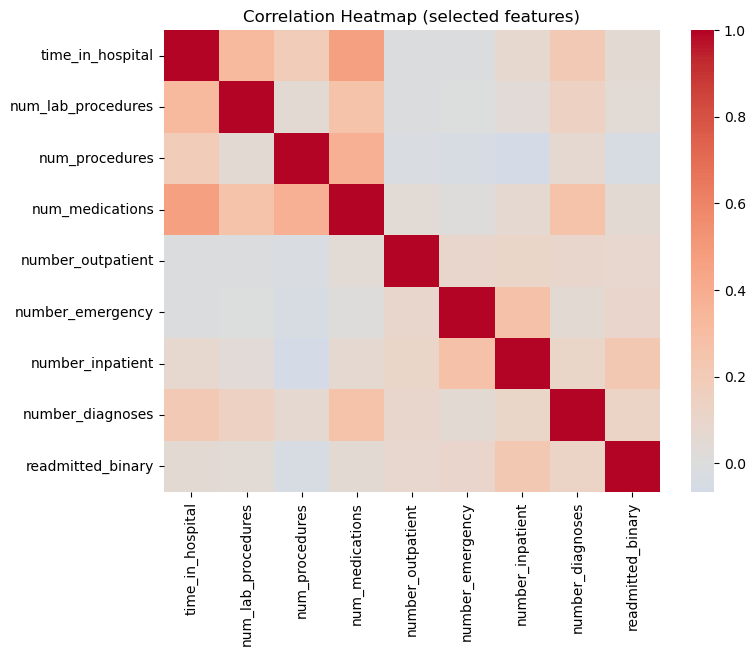

In [23]:
def preprocess_diabetic_data(file_path="./diabetic_data.csv", return_df=False):
    df = pd.read_csv(file_path)
    df.replace("?", np.nan, inplace=True)

    df = df[df["gender"] != "Unknown/Invalid"]
    df = df[~df["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])]

    drop_cols = [
        "encounter_id",
        "patient_nbr",
        "weight",
        "payer_code",
        "medical_specialty",
        "examide",
        "citoglipton",
    ]
    df = df.drop(columns=drop_cols)

    def icd_group(x):
        try:
            x = float(x)
        except Exception:
            return 8
        if 390 <= x <= 459 or x == 785:
            return 0
        if 460 <= x <= 519 or x == 786:
            return 1
        if 520 <= x <= 579 or x == 787:
            return 2
        if 250 <= x < 251:
            return 3
        if 800 <= x <= 999:
            return 4
        if 710 <= x <= 739:
            return 5
        if 580 <= x <= 629 or x == 788:
            return 6
        if 140 <= x <= 239:
            return 7
        return 8

    diag_cols = ["diag_1", "diag_2", "diag_3"]
    for col in diag_cols:
        df[col] = df[col].apply(icd_group).astype("int8")

    drugs = [
        "metformin",
        "repaglinide",
        "nateglinide",
        "chlorpropamide",
        "glimepiride",
        "acetohexamide",
        "glipizide",
        "glyburide",
        "tolbutamide",
        "pioglitazone",
        "rosiglitazone",
        "acarbose",
        "miglitol",
        "troglitazone",
        "tolazamide",
        "insulin",
        "glyburide-metformin",
        "glipizide-metformin",
        "glimepiride-pioglitazone",
        "metformin-rosiglitazone",
        "metformin-pioglitazone",
    ]

    for col in drugs:
        if col in df.columns:
            df[col] = df[col].replace(
                ["No", "Steady", "Up", "Down"],
                [0, 1, 1, 1],
            ).astype("int8")

    df["A1Cresult"] = (
        df["A1Cresult"]
        .replace({">7": 1, ">8": 1, "Norm": 0, "None": -99})
        .fillna(-99)
        .astype("int8")
    )

    df["max_glu_serum"] = (
        df["max_glu_serum"]
        .replace({">200": 1, ">300": 1, "Norm": 0, "None": -99})
        .fillna(-99)
        .astype("int8")
    )

    df["gender"] = df["gender"].map({"Male": 1, "Female": 0}).astype("int8")
    df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0}).astype("int8")
    df["change"] = df["change"].map({"Ch": 1, "No": 0}).astype("int8")

    age_map = {
        "[0-10)": 0,
        "[10-20)": 1,
        "[20-30)": 2,
        "[30-40)": 3,
        "[40-50)": 4,
        "[50-60)": 5,
        "[60-70)": 6,
        "[70-80)": 7,
        "[80-90)": 8,
        "[90-100)": 9,
    }
    df["age"] = df["age"].map(age_map).astype("int8")

    df["race"] = df["race"].fillna(df["race"].mode()[0])

    df["admission_type_id"] = df["admission_type_id"].replace(
        {
            2: 1,
            7: 1,
            6: 5,
            8: 5,
        }
    )

    df["discharge_disposition_id"] = df["discharge_disposition_id"].replace(
        {
            6: 1,
            8: 1,
            9: 1,
            13: 1,
            3: 2,
            4: 2,
            5: 2,
            14: 2,
            22: 2,
            23: 2,
            24: 2,
            12: 10,
            15: 10,
            16: 10,
            17: 10,
            25: 18,
            26: 18,
        }
    )

    df["admission_source_id"] = df["admission_source_id"].replace(
        {
            2: 1,
            3: 1,
            5: 4,
            6: 4,
            10: 4,
            22: 4,
            25: 4,
            15: 9,
            17: 9,
            20: 9,
            21: 9,
            13: 11,
            14: 11,
        }
    )

    df = pd.get_dummies(
        df,
        columns=["race", "admission_type_id", "discharge_disposition_id", "admission_source_id"],
        drop_first=False,
    )

    df["readmitted"] = df["readmitted"].replace({">30": 1, "<30": 1, "NO": 0}).astype("int8")

    X = df.drop(columns=["readmitted"])
    y = df["readmitted"]

    if return_df:
        return X, y, df
    else:
        return X, y


X, y, df_clean = preprocess_diabetic_data(return_df=True)
print("Processed X shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

num_cols_small = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]
corr = pd.concat(
    [df_clean[num_cols_small], y.rename("readmitted_binary")], axis=1
).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (selected features)")
plt.show()


Train/Test Split, Scaling & Balancing

- We’ll use a held-out test set and a downsampled training set for imbalance handling.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


def balance_dataset_downsample(X, y):
    df_train = X.copy()
    df_train["target"] = y.values
    df_majority = df_train[df_train["target"] == 0]
    df_minority = df_train[df_train["target"] == 1]
    df_majority_downsampled = resample(
        df_majority,
        replace=False,
        n_samples=len(df_minority),
        random_state=42
    )
    df_bal = pd.concat([df_majority_downsampled, df_minority])
    df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)
    y_bal = df_bal["target"]
    X_bal = df_bal.drop(columns=["target"])
    return X_bal, y_bal


X_train_bal, y_train_bal = balance_dataset_downsample(X_train, y_train)
print("\nBalanced class counts:\n", y_train_bal.value_counts())

num_cols = X_train_bal.columns

scaler = StandardScaler()
X_train_bal_scaled = X_train_bal.copy()
X_test_scaled = X_test.copy()
X_train_bal_scaled[num_cols] = scaler.fit_transform(X_train_bal_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])


Train shape: (79472, 60)  Test shape: (19868, 60)

Balanced class counts:
 target
1    37453
0    37453
Name: count, dtype: int64


Helper: Training, Evaluation & Comparison

- Central function to train a model + compute metrics.

In [25]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, name="Model"):
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_score) if y_score is not None else float("nan")

    print("Accuracy:  ", f"{acc:.3f}")
    print("Precision: ", f"{prec:.3f}")
    print("Recall:    ", f"{rec:.3f}")
    print("F1-score:  ", f"{f1:.3f}")
    print("ROC-AUC:   ", f"{roc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion matrix:\n", cm)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
        "cm": cm,
    }


def plot_feature_importance(model, feature_names, title):
    if not hasattr(model, "feature_importances_"):
        return
    importances = model.feature_importances_
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    plt.figure(figsize=(8, 6))
    sns.barplot(x="importance", y="feature", data=fi, orient="h")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_model_comparison(results_dict):
    models = list(results_dict.keys())
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    plt.figure(figsize=(10, 5))
    x = np.arange(len(models))
    width = 0.15
    for i, metric in enumerate(metrics):
        vals = [results_dict[m][metric] for m in models]
        plt.bar(x + i * width, vals, width=width, label=metric)
    plt.xticks(x + width * 2, models, rotation=45)
    plt.ylabel("Score")
    plt.title("Model Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


5. Baseline + Advanced Models

- Logistic Regression (baseline)

- Random Forest (advanced tree ensemble)

- SVM with RBF kernel (advanced kernel method)

- Neural Network (MLPClassifier)


=== Logistic Regression (balanced) ===
Accuracy:   0.627
Precision:  0.617
Recall:     0.548
F1-score:   0.580
ROC-AUC:    0.672

Confusion matrix:
 [[7315 3190]
 [4230 5133]]

Classification report:
              precision    recall  f1-score   support

           0       0.63      0.70      0.66     10505
           1       0.62      0.55      0.58      9363

    accuracy                           0.63     19868
   macro avg       0.63      0.62      0.62     19868
weighted avg       0.63      0.63      0.62     19868


=== Random Forest (fixed params) ===
Accuracy:   0.639
Precision:  0.618
Recall:     0.613
F1-score:   0.616
ROC-AUC:    0.688

Confusion matrix:
 [[6965 3540]
 [3625 5738]]

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66     10505
           1       0.62      0.61      0.62      9363

    accuracy                           0.64     19868
   macro avg       0.64      0.64      0.64     19868
w

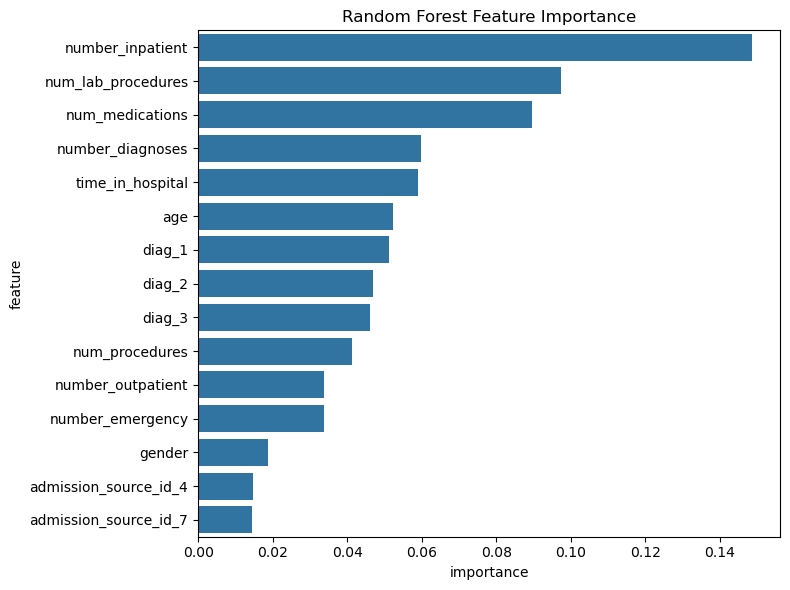


=== MLP Neural Network (fixed) ===
Accuracy:   0.628
Precision:  0.607
Recall:     0.599
F1-score:   0.603
ROC-AUC:    0.677

Confusion matrix:
 [[6874 3631]
 [3752 5611]]

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.65      0.65     10505
           1       0.61      0.60      0.60      9363

    accuracy                           0.63     19868
   macro avg       0.63      0.63      0.63     19868
weighted avg       0.63      0.63      0.63     19868

SVM training size: 20000

=== SVM (RBF kernel, balanced) ===
Accuracy:   0.620
Precision:  0.607
Recall:     0.551
F1-score:   0.578
ROC-AUC:    0.665

Confusion matrix:
 [[7170 3335]
 [4205 5158]]

Classification report:
              precision    recall  f1-score   support

           0       0.63      0.68      0.66     10505
           1       0.61      0.55      0.58      9363

    accuracy                           0.62     19868
   macro avg       0.62      0.62   

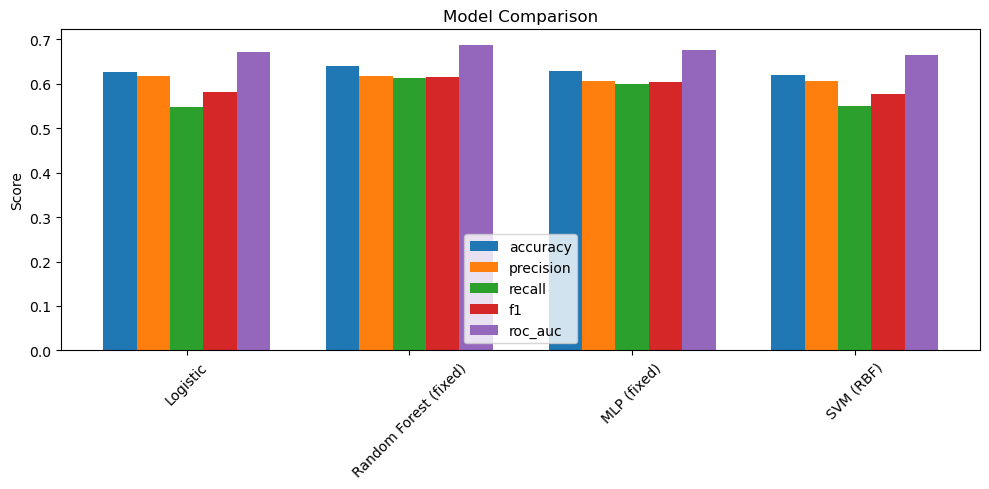

In [26]:
results = {}

log_reg = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    n_jobs=1,
    solver="lbfgs",
)
results["Logistic"] = train_and_evaluate(
    log_reg,
    X_train_bal_scaled, y_train_bal,
    X_test_scaled, y_test,
    name="Logistic Regression (balanced)"
)
best_log_reg = log_reg

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=1
)
results["Random Forest (fixed)"] = train_and_evaluate(
    rf,
    X_train_bal, y_train_bal,
    X_test, y_test,
    name="Random Forest (fixed params)"
)
plot_feature_importance(rf, X_train_bal.columns, "Random Forest Feature Importance")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    random_state=42
)
results["MLP (fixed)"] = train_and_evaluate(
    mlp,
    X_train_bal_scaled, y_train_bal,
    X_test_scaled, y_test,
    name="MLP Neural Network (fixed)"
)

svc = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=False,
    random_state=42
)

max_svm_samples = 20000
n_train = len(X_train_bal_scaled)
if n_train > max_svm_samples:
    svm_idx = np.random.RandomState(42).choice(
        n_train,
        size=max_svm_samples,
        replace=False
    )
    X_train_svm = X_train_bal_scaled.iloc[svm_idx]
    y_train_svm = y_train_bal.iloc[svm_idx]
else:
    X_train_svm = X_train_bal_scaled
    y_train_svm = y_train_bal

print("SVM training size:", X_train_svm.shape[0])
results["SVM (RBF)"] = train_and_evaluate(
    svc,
    X_train_svm, y_train_svm,
    X_test_scaled, y_test,
    name="SVM (RBF kernel, balanced)"
)

plot_model_comparison(results)


6. Cross-Validation & Hyperparameter Tuning (Model Selection)

We’ll do proper CV for Random Forest and SVM to show parameter exploration & complexity control.

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Random Forest best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest best CV ROC-AUC: 0.6846764467229205

=== Random Forest (tuned) ===
Accuracy:   0.636
Precision:  0.615
Recall:     0.610
F1-score:   0.612
ROC-AUC:    0.688

Confusion matrix:
 [[6933 3572]
 [3653 5710]]

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.66      0.66     10505
           1       0.62      0.61      0.61      9363

    accuracy                           0.64     19868
   macro avg       0.64      0.63      0.63     19868
weighted avg       0.64      0.64      0.64     19868


Fitting MLP grid search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END alpha=0.0001, hidden_layer_sizes=(64,), learning_rate_init=0.001; total time=   5.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(64,), learning_rate_init=0.001; total time=   5.4s
[

c:\Users\aznga\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END alpha=0.01, hidden_layer_sizes=(128,), learning_rate_init=0.0005; total time=  17.0s
[CV] END alpha=0.01, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=  10.3s
[CV] END alpha=0.01, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=   8.4s
[CV] END alpha=0.01, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=   8.1s
[CV] END alpha=0.01, hidden_layer_sizes=(128, 64), learning_rate_init=0.0005; total time=   9.7s
[CV] END alpha=0.01, hidden_layer_sizes=(128, 64), learning_rate_init=0.0005; total time=   8.8s
[CV] END alpha=0.01, hidden_layer_sizes=(128, 64), learning_rate_init=0.0005; total time=  13.4s

Neural Network best params: {'alpha': 0.001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.0005}
Neural Network best CV ROC-AUC: 0.6775979464134877

=== MLP Neural Network (tuned) ===
Accuracy:   0.625
Precision:  0.598
Recall:     0.625
F1-score:   0.611
ROC-AUC:    0.679

Confusion matrix:
 [[6574 3931]
 [3511 5852

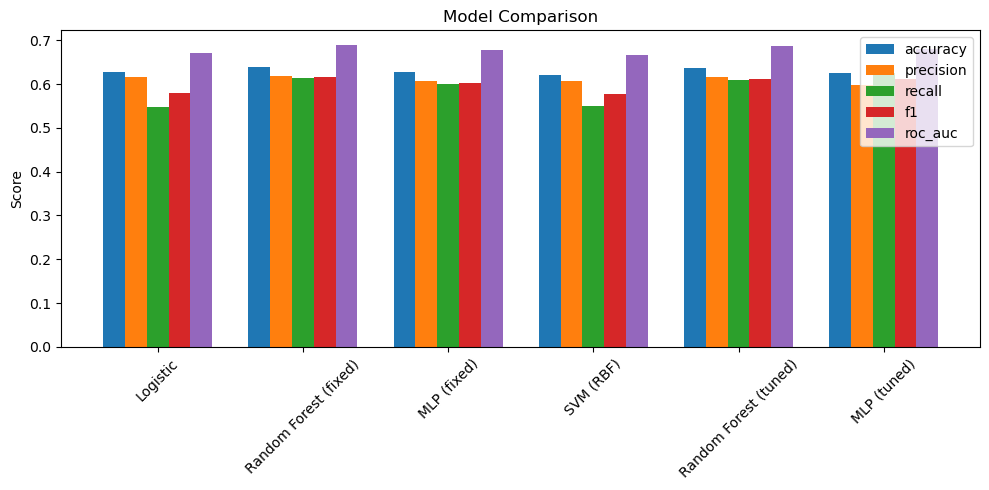

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(random_state=42, n_jobs=1)
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 5]
}
rf_grid = GridSearchCV(
    rf_base,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1
)
rf_grid.fit(X_train_bal, y_train_bal)
print("\nRandom Forest best params:", rf_grid.best_params_)
print("Random Forest best CV ROC-AUC:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
rf_tuned_res = train_and_evaluate(
    best_rf,
    X_train_bal, y_train_bal,
    X_test, y_test,
    name="Random Forest (tuned)"
)
results["Random Forest (tuned)"] = rf_tuned_res

cv_nn = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mlp_base = MLPClassifier(
    activation="relu",
    batch_size=256,
    max_iter=50,
    early_stopping=True,
    random_state=42
)
mlp_param_grid = {
    "hidden_layer_sizes": [
        (64,),
        (128,),
        (128, 64),
    ],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [1e-3, 5e-4]
}
mlp_grid = GridSearchCV(
    estimator=mlp_base,
    param_grid=mlp_param_grid,
    cv=cv_nn,
    scoring="roc_auc",
    n_jobs=1,
    verbose=2
)
print("\nFitting MLP grid search...")
mlp_grid.fit(X_train_bal_scaled, y_train_bal)
print("\nNeural Network best params:", mlp_grid.best_params_)
print("Neural Network best CV ROC-AUC:", mlp_grid.best_score_)

best_mlp = mlp_grid.best_estimator_
mlp_tuned_res = train_and_evaluate(
    best_mlp,
    X_train_bal_scaled, y_train_bal,
    X_test_scaled, y_test,
    name="MLP Neural Network (tuned)"
)
results["MLP (tuned)"] = mlp_tuned_res

plot_model_comparison(results)


7. Under- vs Over-Fitting Analysis

We’ll explicitly vary model complexity and compare training vs validation scores.

Here’s an example for a Decision Tree and Random Forest by varying depth:

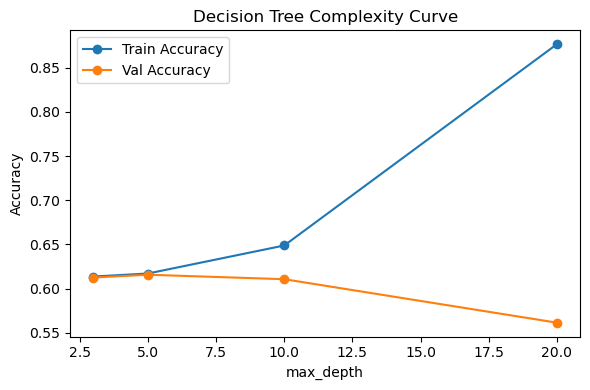

c:\Users\aznga\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


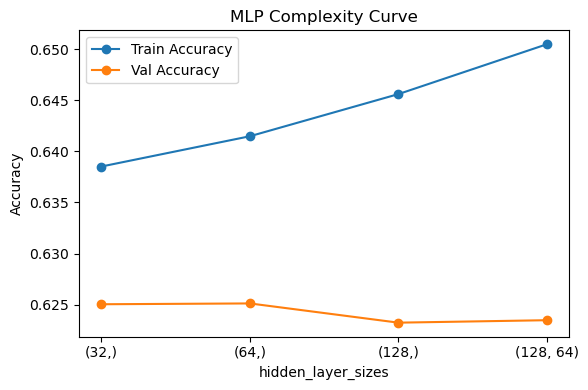

In [28]:
def complexity_curve_decision_tree(X, y, depths, cv):
    train_scores = []
    val_scores = []
    for d in depths:
        tree = DecisionTreeClassifier(
            max_depth=d,
            random_state=42
        )
        cv_train = []
        cv_val = []
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            tree.fit(X_tr, y_tr)
            y_tr_pred = tree.predict(X_tr)
            y_val_pred = tree.predict(X_val)
            cv_train.append(accuracy_score(y_tr, y_tr_pred))
            cv_val.append(accuracy_score(y_val, y_val_pred))
        train_scores.append(np.mean(cv_train))
        val_scores.append(np.mean(cv_val))

    plt.figure(figsize=(6, 4))
    plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
    plt.plot(depths, val_scores, marker="o", label="Val Accuracy")
    plt.xlabel("max_depth")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Complexity Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


depths = [3, 5, 10, 20]
complexity_curve_decision_tree(X_train_bal, y_train_bal, depths, cv)


def complexity_curve_mlp(X, y, hidden_sizes_list, cv):
    train_scores = []
    val_scores = []
    for h in hidden_sizes_list:
        mlp_local = MLPClassifier(
            hidden_layer_sizes=h,
            activation="relu",
            alpha=1e-3,
            batch_size=256,
            learning_rate_init=1e-3,
            max_iter=40,
            early_stopping=True,
            random_state=42
        )
        cv_train = []
        cv_val = []
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            mlp_local.fit(X_tr, y_tr)
            y_tr_pred = mlp_local.predict(X_tr)
            y_val_pred = mlp_local.predict(X_val)
            cv_train.append(accuracy_score(y_tr, y_tr_pred))
            cv_val.append(accuracy_score(y_val, y_val_pred))
        train_scores.append(np.mean(cv_train))
        val_scores.append(np.mean(cv_val))

    labels = [str(h) for h in hidden_sizes_list]
    plt.figure(figsize=(6, 4))
    plt.plot(labels, train_scores, marker="o", label="Train Accuracy")
    plt.plot(labels, val_scores, marker="o", label="Val Accuracy")
    plt.xlabel("hidden_layer_sizes")
    plt.ylabel("Accuracy")
    plt.title("MLP Complexity Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


hidden_sizes_list = [(32,), (64,), (128,), (128, 64)]
complexity_curve_mlp(X_train_bal_scaled, y_train_bal, hidden_sizes_list, cv_nn)


8. (Optional) Cross-Validated ROC Curves

If you want extra polish:

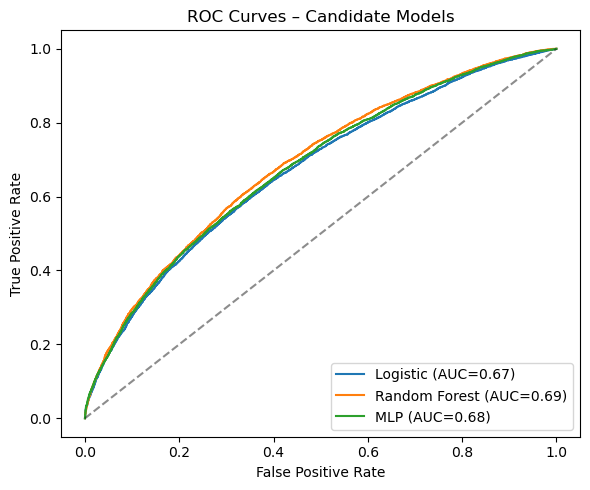

In [29]:
plt.figure(figsize=(6, 5))

y_prob_log = best_log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc(fpr_log, tpr_log):.2f})")

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc(fpr_rf, tpr_rf):.2f})")

y_prob_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC={auc(fpr_mlp, tpr_mlp):.2f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Candidate Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [30]:
df_raw = pd.read_csv("diabetic_data.csv")
df_missing = df_raw.replace("?", np.nan)

missing_percent = (df_missing.isna().mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(
    x=missing_percent.head(15).values,
    y=missing_percent.head(15).index,
    orient="h",
)
plt.xlabel("% Missing")
plt.title("Missingness for Top 15 Columns")
plt.tight_layout()
plt.savefig("fig_missingness.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(6, 4))
sns.countplot(x="readmitted", data=df_raw, order=["NO", "<30", ">30"])
plt.title("Readmission Category Distribution")
plt.xlabel("Readmission category")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("fig_readmission_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8, 4))
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
sns.countplot(x="age", hue="readmitted", data=df_raw, order=age_order)
plt.xticks(rotation=45)
plt.title("Age Group vs Readmission")
plt.tight_layout()
plt.savefig("fig_age_vs_readmit.png", dpi=300, bbox_inches="tight")
plt.close()

importances = best_rf.feature_importances_
feat_names = X_train_bal.columns
fi = (
    pd.DataFrame({"feature": feat_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)
plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=fi, orient="h")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("fig_rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 4))
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Neural Network Training Loss Curve")
plt.tight_layout()
plt.savefig("fig_nn_learning_curve.png", dpi=300, bbox_inches="tight")
plt.close()

depths = [3, 5, 10, 20]
train_scores = []
val_scores = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    cv_train = []
    cv_val = []
    for train_idx, val_idx in cv.split(X_train_bal, y_train_bal):
        X_tr, X_val = X_train_bal.iloc[train_idx], X_train_bal.iloc[val_idx]
        y_tr, y_val = y_train_bal.iloc[train_idx], y_train_bal.iloc[val_idx]
        tree.fit(X_tr, y_tr)
        y_tr_pred = tree.predict(X_tr)
        y_val_pred = tree.predict(X_val)
        cv_train.append(accuracy_score(y_tr, y_tr_pred))
        cv_val.append(accuracy_score(y_val, y_val_pred))
    train_scores.append(np.mean(cv_train))
    val_scores.append(np.mean(cv_val))

plt.figure(figsize=(6, 4))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, val_scores, marker="o", label="Val Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Complexity Curve")
plt.legend()
plt.tight_layout()
plt.savefig("fig_complexity_curve.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved figures:")
print("fig_missingness.png")
print("fig_readmission_distribution.png")
print("fig_age_vs_readmit.png")
print("fig_rf_feature_importance.png")
print("fig_nn_learning_curve.png")
print("fig_complexity_curve.png")


Saved figures:
fig_missingness.png
fig_readmission_distribution.png
fig_age_vs_readmit.png
fig_rf_feature_importance.png
fig_nn_learning_curve.png
fig_complexity_curve.png


In [ ]:
# ============================================================
# SVM RBF: 2D tuning heatmap over C and gamma (fast version)
# ============================================================

# --- Subsample training data to speed up SVM tuning ---
max_svm_heat_samples = 5000
rng = np.random.RandomState(123)

if len(X_train_bal_scaled) > max_svm_heat_samples:
    idx_small = rng.choice(len(X_train_bal_scaled),
                           size=max_svm_heat_samples,
                           replace=False)
    X_svm_heat = X_train_bal_scaled.iloc[idx_small]
    y_svm_heat = y_train_bal.iloc[idx_small]
else:
    X_svm_heat = X_train_bal_scaled
    y_svm_heat = y_train_bal

svm_C_values = [0.1, 1, 10]
svm_gamma_values = [1e-3, 1e-2, 1e-1]

cv_svm = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

svm_scores = np.zeros((len(svm_gamma_values), len(svm_C_values)))

for i, g in enumerate(svm_gamma_values):
    for j, C_val in enumerate(svm_C_values):
        svm_model = SVC(
            kernel="rbf",
            C=C_val,
            gamma=g,
            class_weight="balanced",
            probability=False,   # faster; ROC-AUC uses decision_function
            random_state=42,
        )
        scores = cross_val_score(
            svm_model,
            X_svm_heat,
            y_svm_heat,
            cv=cv_svm,
            scoring="roc_auc",
            n_jobs=1
        )
        svm_scores[i, j] = scores.mean()
        print(f"SVM tuning: C={C_val}, gamma={g}, mean AUC={scores.mean():.3f}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    svm_scores,
    annot=True,
    fmt=".3f",
    xticklabels=svm_C_values,
    yticklabels=svm_gamma_values,
)
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("SVM (RBF) tuning: CV ROC-AUC over C and gamma\n(on 5k-sample subset)")
plt.tight_layout()
plt.savefig("fig_svm_tuning_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved SVM tuning heatmap: fig_svm_tuning_heatmap.png")
